# 지우 eda

**1.요일별 매출 비중 ↔ 유동인구 비율 일치 여부**

In [27]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [28]:
#컬럼 정리
요일_매출 = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액','목요일_매출_금액',
            '금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']
요일_유동 = ['월요일_유동인구_수','화요일_유동인구_수','수요일_유동인구_수','목요일_유동인구_수',
            '금요일_유동인구_수','토요일_유동인구_수','일요일_유동인구_수']
요일라벨 = ['월','화','수','목','금','토','일']

In [29]:
# ── 매출: 상권 단위로 요일별 합산 (업종 합침) ──
sales_day = sales.groupby(
    ['기준_년분기_코드','상권_코드','상권_구분_코드_명']
)[요일_매출].sum().reset_index()

sales_day

,기준_년분기_코드,상권_코드,상권_구분_코드_명,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액
0,20201,3001491,관광특구,7373422807,7469821477,8796688378,8946426841,11022093262,16593714031,14300609579
1,20201,3001492,관광특구,37379697278,43127033576,42004385982,44028647967,43659575670,32084561027,15936447857
2,20201,3001493,관광특구,10802317925,13906134889,13356706291,11926373877,14621056348,11734228080,9605497529
3,20201,3001494,관광특구,34607908059,33249602089,32898112756,33786322893,37963820152,24152404739,9328377020
4,20201,3001495,관광특구,19296379832,19931009283,21265514540,23156704641,25715579224,33800937313,28536968356
...,...,...,...,...,...,...,...,...,...,...
37653,20254,3130323,전통시장,1627603819,1704047737,1939872137,1808925921,2484841572,2788227883,1959300376
37654,20254,3130324,전통시장,552827176,845709486,1126524253,1015853340,1160237874,1627333823,1086730705
37655,20254,3130325,전통시장,490986101,434867132,550934237,514550840,632542505,604572252,452356955
37656,20254,3130326,전통시장,2550441983,2401771824,2464355697,2133678328,2751381769,2388946023,925523150


In [30]:
#유동인구랑 sales_day 합치기
merged_day = sales_day.merge(
    floating[['기준_년분기_코드','상권_코드'] + 요일_유동],
    on=['기준_년분기_코드','상권_코드'],
    how='inner'
)
print(f'유동인구와 sales_day가 합쳐진 행 수: {merged_day.shape[0]:,}행')

유동인구와 sales_day가 합쳐진 행 수: 37,642행


In [31]:
# 요일별 비중(%) 계산 및 매출-유동 갭 계산
매출합 = merged_day[요일_매출].sum(axis=1)
유동합 = merged_day[요일_유동].sum(axis=1)
 
for i, day in enumerate(요일라벨):
    merged_day[f'매출비중_{day}'] = merged_day[요일_매출[i]] / 매출합 * 100
    merged_day[f'유동비중_{day}'] = merged_day[요일_유동[i]] / 유동합 * 100
    merged_day[f'갭_{day}'] = merged_day[f'매출비중_{day}'] - merged_day[f'유동비중_{day}']

In [32]:
# 상권구분별 요일 비중 비교
상권 = ['골목상권','발달상권','관광특구','전통시장']
 
print(' 상권구분별 요일 비중 비교 (매출% vs 유동인구%)')
 
for 구분 in 상권:
    sub = merged_day[merged_day['상권_구분_코드_명'] == 구분]
    매출비중 = [sub[f'매출비중_{d}'].mean() for d in 요일라벨]
    유동비중 = [sub[f'유동비중_{d}'].mean() for d in 요일라벨]
    차이 = [m - f for m, f in zip(매출비중, 유동비중)]
 
    print(f'\n▸ {구분} ')
    print(f'  매출%: {" | ".join([f"{v:5.1f}" for v in 매출비중])}')
    print(f'  유동%: {" | ".join([f"{v:5.1f}" for v in 유동비중])}')
    print(f'  차이 : {" | ".join([f"{v:+5.1f}" for v in 차이])}')

 상권구분별 요일 비중 비교 (매출% vs 유동인구%)

▸ 골목상권 
  매출%:  14.5 |  14.9 |  14.9 |  15.0 |  16.2 |  14.8 |   9.8
  유동%:  14.3 |  14.3 |  14.3 |  14.3 |  14.2 |  14.2 |  14.4
  차이 :  +0.2 |  +0.6 |  +0.6 |  +0.7 |  +2.0 |  +0.5 |  -4.6

▸ 발달상권 
  매출%:  15.1 |  15.6 |  15.3 |  15.5 |  16.8 |  13.7 |   8.0
  유동%:  14.7 |  15.0 |  15.0 |  15.1 |  15.0 |  13.1 |  12.2
  차이 :  +0.4 |  +0.6 |  +0.3 |  +0.4 |  +1.8 |  +0.5 |  -4.1

▸ 관광특구 
  매출%:  12.9 |  13.7 |  14.1 |  14.4 |  15.8 |  16.8 |  12.3
  유동%:  14.6 |  15.1 |  15.3 |  15.5 |  15.5 |  12.9 |  11.1
  차이 :  -1.7 |  -1.4 |  -1.2 |  -1.2 |  +0.3 |  +3.9 |  +1.3

▸ 전통시장 
  매출%:  14.1 |  14.3 |  14.5 |  14.8 |  16.3 |  16.3 |   9.7
  유동%:  14.3 |  14.3 |  14.4 |  14.4 |  14.4 |  14.4 |  13.9
  차이 :  -0.1 |  -0.0 |  +0.1 |  +0.4 |  +1.9 |  +1.9 |  -4.1


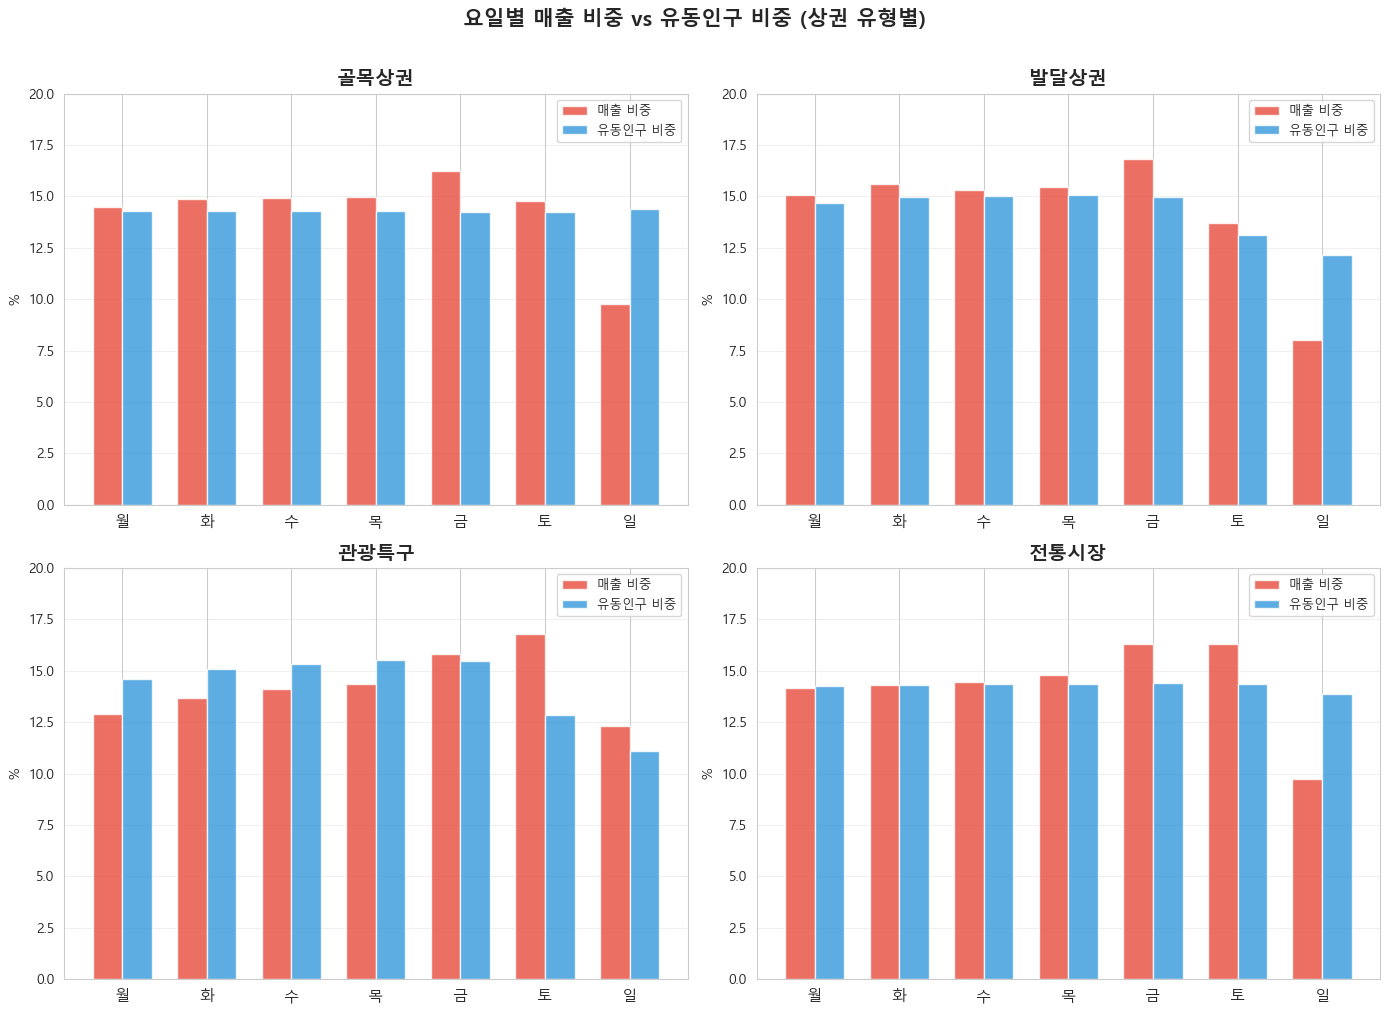

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
색_매출 = '#E74C3C'
색_유동 = '#3498DB'
 
for idx, 구분 in enumerate(상권):
    ax = axes[idx]
    sub = merged_day[merged_day['상권_구분_코드_명'] == 구분]
 
    매출비중 = [sub[f'매출비중_{d}'].mean() for d in 요일라벨]
    유동비중 = [sub[f'유동비중_{d}'].mean() for d in 요일라벨]
 
    x = np.arange(7)
    w = 0.35
    ax.bar(x - w/2, 매출비중, w, color=색_매출, alpha=0.8, label='매출 비중')
    ax.bar(x + w/2, 유동비중, w, color=색_유동, alpha=0.8, label='유동인구 비중')
 
    ax.set_xticks(x)
    ax.set_xticklabels(요일라벨, fontsize=11)
    ax.set_title(구분, fontsize=14, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 20)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
 
fig.suptitle('요일별 매출 비중 vs 유동인구 비중 (상권 유형별)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### - 금요일: 모든 상권에서 매출 > 유동인구 → 1인당 소비가 높음 (회식·모임 효과)
### - 일요일: 관광특구 제외 3개 상권에서 매출 << 유동인구 → 사람은 있지만 소비 안 함

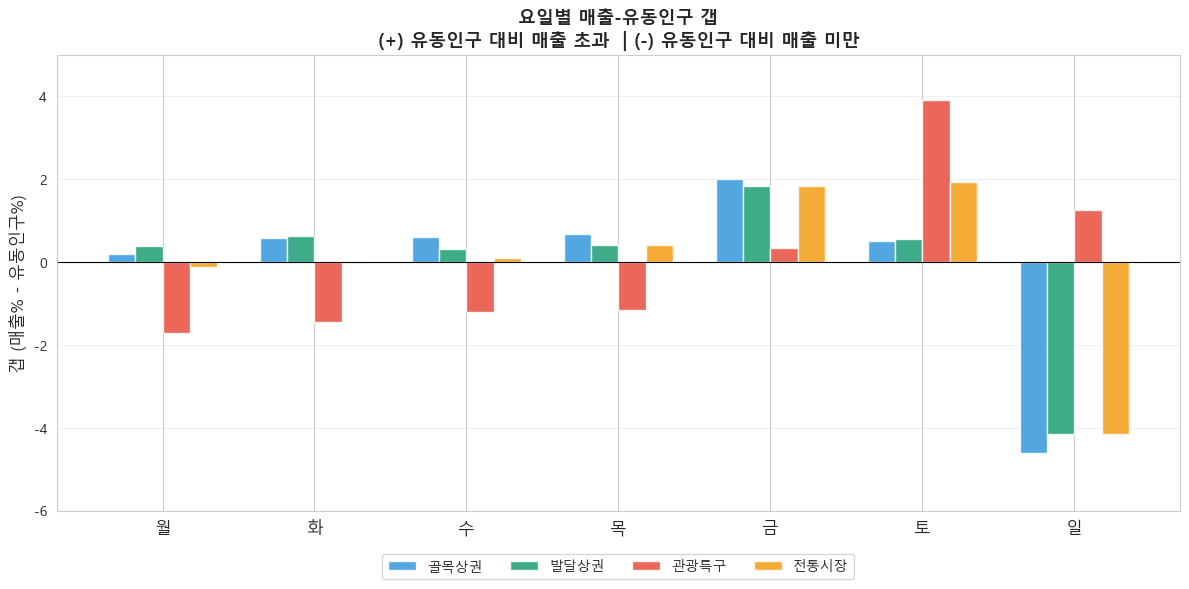

In [40]:
# %% 갭 차트 (매출비중 - 유동비중)
색상 = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}
 
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(7)
w = 0.18
 
for i, 구분 in enumerate(상권):
    sub = merged_day[merged_day['상권_구분_코드_명'] == 구분]
    gaps = [sub[f'갭_{d}'].mean() for d in 요일라벨]
    ax.bar(x + i*w - 1.5*w, gaps, w, color=색상[구분], alpha=0.85, label=구분)
 
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(요일라벨, fontsize=12)
ax.set_ylabel('갭 (매출% - 유동인구%)', fontsize=12)
ax.set_title('요일별 매출-유동인구 갭\n(+) 유동인구 대비 매출 초과  | (-) 유동인구 대비 매출 미만',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08))
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-6, 5)
plt.tight_layout()
plt.show()


### **관광특구만 정반대 패턴**
### - 평일(월~목): 유동인구 대비 매출 부족 (-1.2~1.7%p) → 구경만 하는 유동인구 많음
### - 토요일: +3.9%p 매출 폭발 → 주말 관광객의 구매력이 평일보다 훨씬 높음
### - 일요일도 +1.3%p (유일하게 플러스)

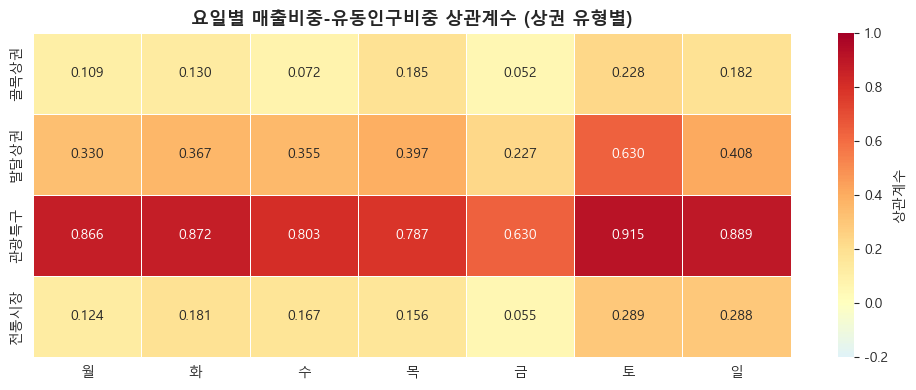


 평균 상관계수:
  골목상권: 0.137
  발달상권: 0.388
  관광특구: 0.823
  전통시장: 0.180


In [43]:
# %% 요일별 상관계수 히트맵
corr_data = []
 
for 구분 in 상권:
    sub = merged_day[merged_day['상권_구분_코드_명'] == 구분]
    row = []
    for d in 요일라벨:
        c = sub[[f'매출비중_{d}', f'유동비중_{d}']].corr().iloc[0, 1]
        row.append(c)
    corr_data.append(row)
 
corr_df = pd.DataFrame(corr_data, index=상권, columns=요일라벨)
 
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.2, vmax=1.0, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})
ax.set_title('요일별 매출비중-유동인구비중 상관계수 (상권 유형별)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
 
print('\n 평균 상관계수:')
for 구분 in 상권:
    print(f'  {구분}: {corr_df.loc[구분].mean():.3f}')

### **상관계수 해석**
### - 관광특구 0.823: 유동인구 -> 매출 (강한 연결)
### - 발달상권 0.388: 중간 수준
### - 골목상권 0.137 / 전통시장 0.180: 유동인구와 매출이 거의 무관
### → 단골·목적형 소비 중심, 지나가는 사람 수와 매출이 연동되지 않음

In [46]:
# %% 관광특구 업종별 토요일 편향 분석
관광 = sales[sales['상권_구분_코드_명'] == '관광특구']
 
# 업종별 요일 매출 합산
업종요일_관광 = 관광.groupby('서비스_업종_코드_명')[요일_매출].sum()
업종요일_관광['총매출'] = 업종요일_관광.sum(axis=1)
 
for i, d in enumerate(요일라벨):
    업종요일_관광[f'비중_{d}'] = 업종요일_관광[요일_매출[i]] / 업종요일_관광['총매출'] * 100
 
# 토요일 편향 = 토요일비중 - 평일(월~목)평균비중
업종요일_관광['평일평균비중'] = 업종요일_관광[['비중_월','비중_화','비중_수','비중_목']].mean(axis=1)
업종요일_관광['토요일_편향'] = 업종요일_관광['비중_토'] - 업종요일_관광['평일평균비중']

업종요일_관광['토요일_편향']

서비스_업종_코드_명
PC방        7.77
가구         6.92
가방         5.43
가전제품       8.65
가전제품수리    -6.16
           ... 
한의원       -2.62
핸드폰       -2.74
호프-간이주점    8.04
화장품       -0.10
화초        -8.46
Name: 토요일_편향, Length: 61, dtype: float64

In [47]:
# 매출 하위 25% 제외 (노이즈 제거)
cutoff = 업종요일_관광['총매출'].quantile(0.25)
업종요일_필터 = 업종요일_관광[업종요일_관광['총매출'] > cutoff].copy()

In [49]:
# 토요일 편향 TOP 10
토편향top = 업종요일_필터.sort_values('토요일_편향', ascending=False).head(10)
print('🔥 관광특구에서 토요일 편향이 가장 큰 업종 TOP 10')
print('  (토요일 비중 - 평일 평균 비중)')
print('-' * 55)
for 업종, row in 토편향top.iterrows():
    print(f'  {업종}: +{row["토요일_편향"]:.1f}%p'
          f'  (토 {row["비중_토"]:.1f}% vs 평일 {row["평일평균비중"]:.1f}%)')

🔥 관광특구에서 토요일 편향이 가장 큰 업종 TOP 10
  (토요일 비중 - 평일 평균 비중)
-------------------------------------------------------
  완구: +16.5%p  (토 26.4% vs 평일 10.0%)
  미용실: +11.1%p  (토 22.9% vs 평일 11.7%)
  운동/경기용품: +10.8%p  (토 22.2% vs 평일 11.4%)
  양식음식점: +10.6%p  (토 21.9% vs 평일 11.2%)
  안경: +9.0%p  (토 21.7% vs 평일 12.7%)
  가전제품: +8.7%p  (토 20.4% vs 평일 11.8%)
  노래방: +8.6%p  (토 20.8% vs 평일 12.3%)
  호프-간이주점: +8.0%p  (토 20.2% vs 평일 12.1%)
  가구: +6.9%p  (토 20.0% vs 평일 13.1%)
  일반의류: +5.7%p  (토 18.8% vs 평일 13.1%)


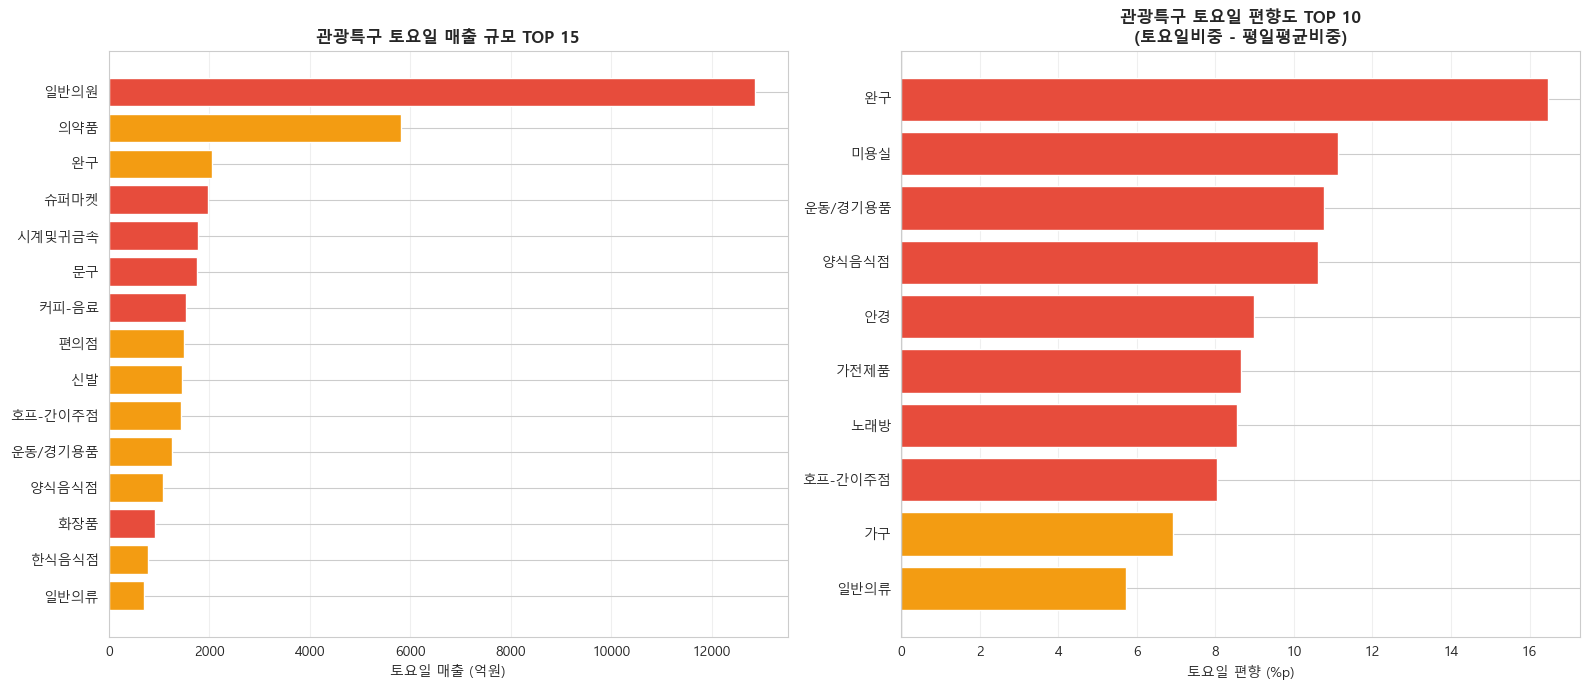

In [52]:
# %% 관광특구 토요일 매출 TOP 15 시각화
토매출top = 업종요일_필터.sort_values('토요일_매출_금액', ascending=False).head(15).copy()
토매출top['토매출_억'] = 토매출top['토요일_매출_금액'] / 1e8
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
y_pos = range(len(토매출top) - 1, -1, -1)
bars = ax1.barh(y_pos, 토매출top['토매출_억'].values,
                color=['#E74C3C' if v > 5 else '#F39C12' for v in 토매출top['토요일_편향'].values],
                edgecolor='white')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(토매출top.index[::-1])
ax1.set_xlabel('토요일 매출 (억원)')
ax1.set_title('관광특구 토요일 매출 규모 TOP 15', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

토편향top_sorted = 토편향top.sort_values('토요일_편향')
ax2 = axes[1]
colors = ['#E74C3C' if v > 8 else '#F39C12' if v > 5 else '#3498DB'
          for v in 토편향top_sorted['토요일_편향'].values]
ax2.barh(range(len(토편향top_sorted)), 토편향top_sorted['토요일_편향'].values, color=colors, edgecolor='white')
ax2.set_yticks(range(len(토편향top_sorted)))
ax2.set_yticklabels(토편향top_sorted.index)
ax2.set_xlabel('토요일 편향 (%p)')
ax2.set_title('관광특구 토요일 편향도 TOP 10\n(토요일비중 - 평일평균비중)', fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
plt.show()

- **매출 규모** 기준: 일반의류(1,286억), 한식음식점(582억), 화장품(205억) 순
- **토요일 편향** 기준: 완구(+16.5%p), 미용실(+11.1%p), 운동/경기용품(+10.8%p), 양식음식점(+10.6%p)
- 의류·신발·가전 등 **쇼핑형 업종**과 양식·주점 등 **여가형 업종**이 토요일 매출을 주도
- 한식·커피·편의점은 토요일에도 비중 변화 없음 → 요일에 무관한 일상 소비 → 관광특구 토요일 매출 폭발은 **"주말 쇼핑 + 외식 여가"** 수요가 핵심 원인

In [55]:
# %% 전 상권 업종별 일요일 매출 수준 분류
# 일요일 매출 / 평일 평균 매출 비율로 업종 분류
업종요일_전체 = sales.groupby('서비스_업종_코드_명')[요일_매출 + ['당월_매출_금액']].sum()
업종요일_전체['평일평균'] = 업종요일_전체[['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액',
                                  '목요일_매출_금액','금요일_매출_금액']].mean(axis=1)
업종요일_전체['일_vs_평일'] = 업종요일_전체['일요일_매출_금액'] / 업종요일_전체['평일평균']
 
# 매출 하위 10% 제외
cutoff = 업종요일_전체['당월_매출_금액'].quantile(0.1)
업종분류 = 업종요일_전체[업종요일_전체['당월_매출_금액'] > cutoff].copy()

In [56]:
업종분류['유형'] = pd.cut(
    업종분류['일_vs_평일'],
    bins=[0, 0.1, 0.5, 0.8, 1.5, 100],
    labels=['완전휴무(~10%)', '대폭감소(10~50%)', '소폭감소(50~80%)', '유지(80~150%)', '증가(150%+)']
)

In [57]:
분류요약 = 업종분류.groupby('유형').agg(
    업종수=('당월_매출_금액', 'count'),
    매출합_억=('당월_매출_금액', lambda x: x.sum() / 1e8)
)
분류요약['매출비중'] = 분류요약['매출합_억'] / 분류요약['매출합_억'].sum() * 100
 
print('📊 일요일 매출 수준별 업종 분류 (전체 상권)')
print('  일요일 매출 / 평일 평균 매출 비율 기준')
print('-' * 55)
print(f'{"유형":<20} {"업종수":>6} {"매출합(억)":>12} {"매출비중":>8}')
for name, row in 분류요약.iterrows():
    print(f'{name:<20} {row["업종수"]:>5.0f} {row["매출합_억"]:>11,.0f} {row["매출비중"]:>7.1f}%')
 

📊 일요일 매출 수준별 업종 분류 (전체 상권)
  일요일 매출 / 평일 평균 매출 비율 기준
-------------------------------------------------------
유형                      업종수       매출합(억)     매출비중
완전휴무(~10%)               6     945,033    18.2%
대폭감소(10~50%)            17     750,761    14.4%
소폭감소(50~80%)            11   1,722,193    33.1%
유지(80~150%)             20   1,712,937    33.0%
증가(150%+)                2      64,953     1.3%


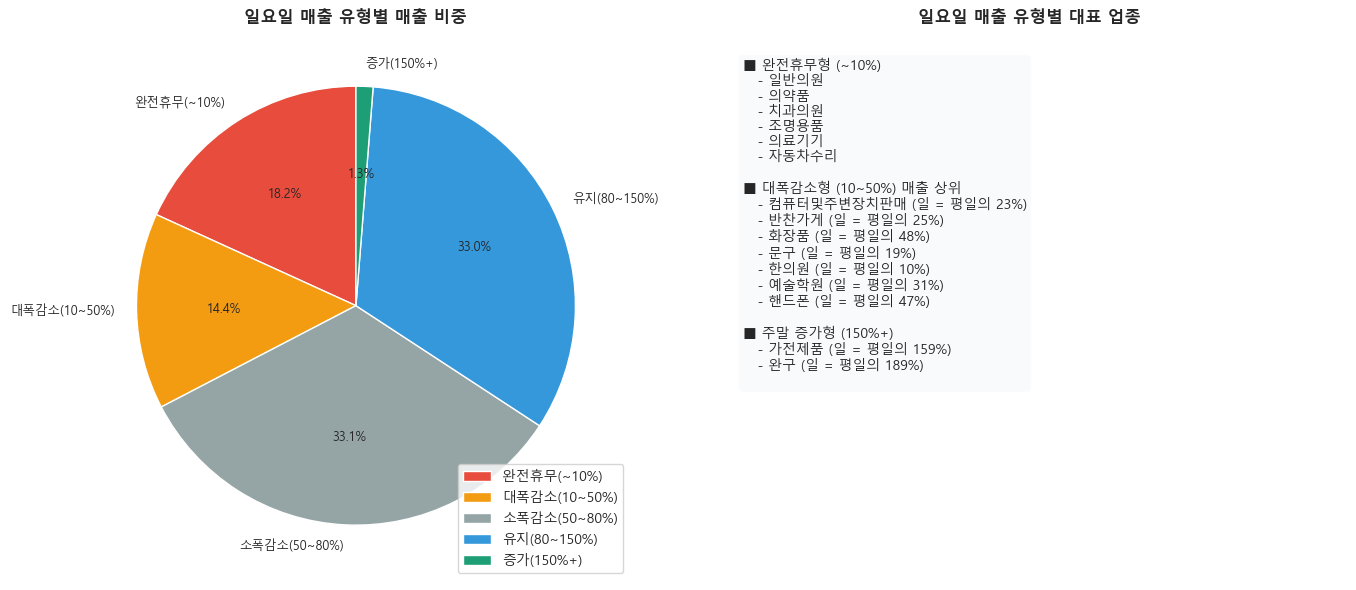

In [ ]:
# %% 일요일 매출 분류 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 파이차트: 매출 비중
ax1 = axes[0]
파이색 = ['#E74C3C', '#F39C12', '#95A5A6', '#3498DB', '#1D9E75']
분류요약.plot.pie(y='매출비중', ax=ax1, colors=파이색, autopct='%1.1f%%',
               startangle=90, labels=분류요약.index, fontsize=9)
ax1.set_ylabel('')
ax1.set_title('일요일 매출 유형별 매출 비중', fontweight='bold')
 
# (2) 대표 업종 리스트
ax2 = axes[1]
ax2.axis('off')
 
text = '■ 완전휴무형 (~10%)\n'
for name in 업종분류[업종분류['유형'] == '휴무(~10%)'].sort_values('당월_매출_금액', ascending=False).index:
    text += f'   - {name}\n'
 
text += '\n■ 대폭감소형 (10~50%) 매출 상위\n'
대폭 = 업종분류[업종분류['유형'] == '대폭감소(10~50%)'].sort_values('당월_매출_금액', ascending=False).head(7)
for name, row in 대폭.iterrows():
    text += f'   - {name} (일 = 평일의 {row["일_vs_평일"]*100:.0f}%)\n'
 
text += '\n■ 주말 증가형 (150%+)\n'
for name, row in 업종분류[업종분류['유형'] == '증가(150%+)'].sort_values('당월_매출_금액', ascending=False).iterrows():
    text += f'   - {name} (일 = 평일의 {row["일_vs_평일"]*100:.0f}%)\n'

ax2.text(0.05, 0.95, text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#F8F9FA', alpha=0.8))
ax2.set_title('일요일 매출 유형별 대표 업종', fontweight='bold')
 
plt.tight_layout()
plt.show()

In [63]:
# %% 관광특구 상권별 토일 비중 비교
상권별 = 관광.groupby('상권_코드_명')[['토요일_매출_금액', '일요일_매출_금액', '당월_매출_금액']].sum()
상권별['토비중'] = 상권별['토요일_매출_금액'] / 상권별['당월_매출_금액'] * 100
상권별['일비중'] = 상권별['일요일_매출_금액'] / 상권별['당월_매출_금액'] * 100
상권별['토일갭'] = 상권별['토비중'] - 상권별['일비중']
상권별 = 상권별.sort_values('당월_매출_금액', ascending=False)
 
print('📊 관광특구 개별 상권 토-일 매출 패턴')
print(f'{"상권명":<25} {"총매출(억)":>10} {"토비중":>8} {"일비중":>8} {"토-일갭":>8}')
print('-' * 65)
for name, row in 상권별.iterrows():
    print(f'{name:<25} {row["당월_매출_금액"]/1e8:>9,.0f}'
          f' {row["토비중"]:>7.1f}% {row["일비중"]:>7.1f}% {row["토일갭"]:>+7.1f}%p')

📊 관광특구 개별 상권 토-일 매출 패턴
상권명                           총매출(억)      토비중      일비중     토-일갭
-----------------------------------------------------------------
명동 남대문 북창동 다동 무교동 관광특구       94,758    13.0%     6.2%    +6.7%p
잠실 관광특구                      59,343    19.8%    17.1%    +2.6%p
종로·청계 관광특구                   47,869    12.9%     6.7%    +6.2%p
강남 마이스 관광특구                  36,954    17.0%    14.9%    +2.1%p
동대문패션타운 관광특구                 25,725    14.9%    10.8%    +4.1%p
이태원 관광특구                     20,524    23.4%    18.9%    +4.5%p
종로?청계 관광특구                    9,787    13.7%     7.8%    +5.8%p


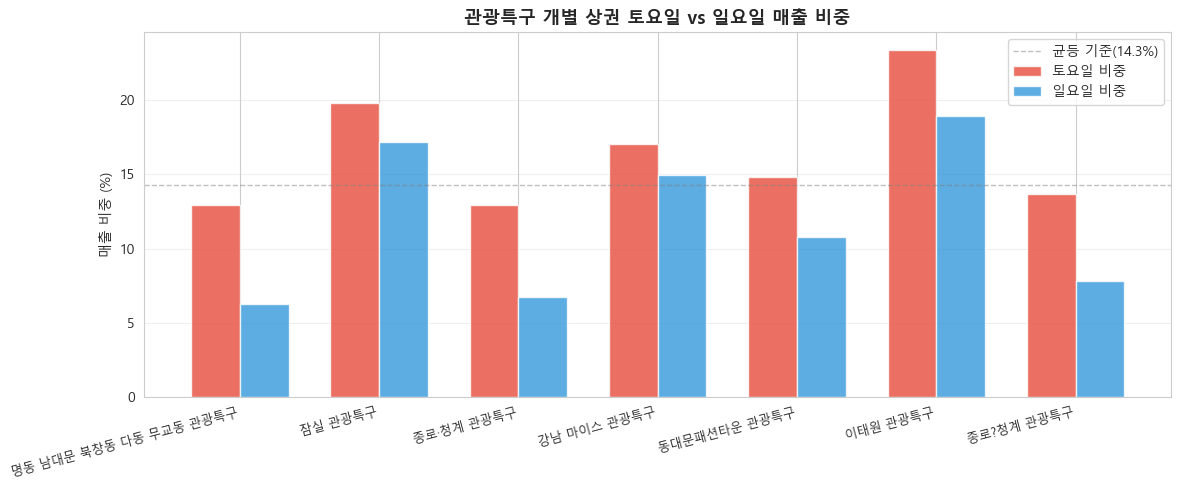

In [64]:
# %% 관광특구 상권별 시각화
fig, ax = plt.subplots(figsize=(12, 5))
상권명 = 상권별.index.tolist()
x = np.arange(len(상권명))
w = 0.35
 
ax.bar(x - w/2, 상권별['토비중'].values, w, color='#E74C3C', alpha=0.8, label='토요일 비중')
ax.bar(x + w/2, 상권별['일비중'].values, w, color='#3498DB', alpha=0.8, label='일요일 비중')
 
# 14.3% 기준선 (7일 균등 = 100/7)
ax.axhline(100/7, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='균등 기준(14.3%)')
 
ax.set_xticks(x)
ax.set_xticklabels(상권명, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('매출 비중 (%)')
ax.set_title('관광특구 개별 상권 토요일 vs 일요일 매출 비중', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()